# Лабораторная 2 (GPU-вариант): декодерный трансформер на `Tiny Shakespeare`

Цель работы: выполнить расширенный перенос на реальный корпус в режиме `GPU-friendly`,
увеличить масштаб модели и подтвердить улучшение относительно `CPU`-варианта.

## Что нужно знать до старта
- Полностью завершён `CPU`-вариант `ЛР02` с зафиксированным `test_perplexity`.
- GPU-среда проходит `gpu_preflight()` без fallback и нестабильных kernels.
- Контракт gate-критериев остаётся тем же: сравнение с baseline + generation checks.

## Интуиция задачи без формул
GPU-вариант не меняет математику задачи, а масштабирует обучение в пределах зафиксированного бюджета.
Если `gpu_preflight`, causal-mask и leakage checks выполнены, улучшение качества объясняется обучением модели, а не сменой условий эксперимента.

## Контракт данных (быстрый ориентир)
- `token_windows` и `targets`: формы `(batch, context)` как в CPU-треке.
- `padding_mask`: исключает `PAD` из loss/metric.
- `causal_mask`: строго нижнетреугольная, без доступа к будущим позициям.
- `gpu_preflight`: обязательный preflight до длинного обучения, без скрытого CPU fallback.
- Итоговые проверки: baseline/perplexity/generation/leakage + индикатор `CPU_REFERENCE_PERPLEXITY`.



## Маршрут выполнения

Строгий порядок шагов:
1. Завершить `CPU`-вариант `ЛР02` и зафиксировать `test_perplexity`.
2. `TODO 1`: загрузка корпуса и построение словаря.
3. `TODO 2`: окна фиксированной длины и индексное разбиение.
4. `TODO 3`: декодерный блок с причинной маской.
5. `TODO 4`: обучение, метрики и сравнение с частотным ориентиром.
6. `TODO 5`: детерминированная генерация по фиксированным подсказкам.
7. `TODO 6`: диагностика внимания без доступа в будущее.


In [1]:
import ctypes
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "kaggle-gpu")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/remote-worker-prof/edu-ai-math-essentials.git",
)
NOTEBOOK_REQUIREMENTS = "themes/04-Autoregression/lab/requirements.txt"


def _prepend_path_env(var_name: str, new_paths: list[Path]) -> None:
    """Добавляет пути в начало переменной окружения с путями.

    Аргументы:
      var_name: Имя переменной окружения (например, `LD_LIBRARY_PATH`).
      new_paths: Пути-кандидаты, которые нужно добавить в начало.

    Возвращает:
      `None`.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    existing = os.environ.get(var_name, "")
    cleaned_new = []
    for path in new_paths:
        if path.is_dir():
            cleaned_new.append(str(path))

    if not cleaned_new:
        return

    existing_parts = [part for part in existing.split(":") if part]
    merged = []
    for part in cleaned_new + existing_parts:
        if part not in merged:
            merged.append(part)
    os.environ[var_name] = ":".join(merged)


def _detect_site_packages_dir() -> Path | None:
    """Находит каталог `site-packages` активной виртуальной среды.

    Аргументы:
      Нет.

    Возвращает:
      Путь к `site-packages` или `None`, если каталог не найден.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    major, minor = sys.version_info[:2]
    candidate = Path(sys.prefix) / "lib" / f"python{major}.{minor}" / "site-packages"
    if candidate.is_dir():
        return candidate
    return None


def _preload_cuda_runtime_libraries(site_packages: Path) -> dict:
    """Предзагружает CUDA-библиотеки в текущий процесс до импорта TensorFlow.

    Аргументы:
      site_packages: Каталог `site-packages` активной виртуальной среды.

    Возвращает:
      Сводка со списками успешно загруженных, отсутствующих и проблемных библиотек.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    nvidia_root = site_packages / "nvidia"
    library_specs = [
        ("cuda_runtime", "libcudart.so.12"),
        ("cublas", "libcublas.so.12"),
        ("cublas", "libcublasLt.so.12"),
        ("cudnn", "libcudnn.so.9"),
        ("cufft", "libcufft.so.11"),
        ("curand", "libcurand.so.10"),
        ("cusolver", "libcusolver.so.11"),
        ("cusparse", "libcusparse.so.12"),
        ("nccl", "libnccl.so.2"),
        ("nvjitlink", "libnvJitLink.so.12"),
    ]

    loaded = []
    missing = []
    failed = []

    for subdir, library_name in library_specs:
        library_path = nvidia_root / subdir / "lib" / library_name
        if not library_path.is_file():
            missing.append(str(library_path))
            continue
        try:
            ctypes.CDLL(str(library_path), mode=ctypes.RTLD_GLOBAL)
            loaded.append(str(library_path))
        except OSError as exc:
            failed.append(f"{library_path}: {exc}")

    return {
        "loaded": loaded,
        "missing": missing,
        "failed": failed,
    }


def _configure_local_gpu_runtime_env(runtime_mode: str) -> dict:
    """Готовит переменные окружения для локального запуска TensorFlow на GPU.

    Аргументы:
      runtime_mode: Запрошенный режим выполнения тетради.

    Возвращает:
      Словарь с краткой сводкой применённой настройки путей.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if runtime_mode != "local-gpu":
        return {
            "applied": False,
            "reason": "runtime_mode != local-gpu",
        }

    site_packages = _detect_site_packages_dir()
    if site_packages is None:
        return {
            "applied": False,
            "reason": "site-packages not found",
        }

    tensorflow_dir = site_packages / "tensorflow"
    nvidia_root = site_packages / "nvidia"
    nvidia_lib_dirs = sorted(path for path in nvidia_root.glob("*/lib") if path.is_dir())
    _prepend_path_env("LD_LIBRARY_PATH", [tensorflow_dir, *nvidia_lib_dirs])

    nvcc_bin = nvidia_root / "cuda_nvcc" / "bin"
    _prepend_path_env("PATH", [nvcc_bin])

    preload_report = _preload_cuda_runtime_libraries(site_packages)

    return {
        "applied": True,
        "tensorflow_dir": str(tensorflow_dir),
        "nvidia_lib_dirs": [str(path) for path in nvidia_lib_dirs],
        "nvcc_bin": str(nvcc_bin),
        "preload_report": preload_report,
    }


gpu_env_info = _configure_local_gpu_runtime_env(RUNTIME_MODE)
print("gpu_env_info:", gpu_env_info)


def _detect_notebook_platform():
    """Определяет тип среды выполнения текущей тетради.

    Аргументы:
      Нет.

    Возвращает:
      Строка из множества `{'local', 'colab', 'kaggle'}`.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    """Проверяет, похож ли путь на корень учебного репозитория.

    Аргументы:
      path: Проверяемый путь.

    Возвращает:
      `True`, если обнаружены ключевые признаки корня репозитория.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    """Возвращает стандартный путь клонирования для облачной платформы.

    Аргументы:
      platform: Имя платформы (`'colab'` или `'kaggle'`).

    Возвращает:
      Абсолютный путь каталога репозитория.

    Исключения:
      ValueError: Если передано неподдерживаемое имя платформы.
    """
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    """Проверяет, остался ли в настройке шаблонный URL репозитория.

    Аргументы:
      repo_url: Проверяемый URL репозитория.

    Возвращает:
      `True`, если URL имеет вид шаблона-заглушки.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    """Ищет корень курса, поднимаясь от текущего каталога вверх.

    Аргументы:
      Нет.

    Возвращает:
      Объект `Path` корня репозитория или `None`, если путь не найден.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    """Обеспечивает доступность модуля `course_runtime` для текущей среды.

    Аргументы:
      runtime_mode: Режим запуска тетради.
      repo_url: URL репозитория курса для облачной автозагрузки.

    Возвращает:
      `None`.

    Исключения:
      ModuleNotFoundError: Если локальный запуск выполнен вне корректного корня репозитория.
      RuntimeError: Если в облаке отсутствует валидный URL репозитория или каталог повреждён.
      subprocess.CalledProcessError: Если команда `git clone` завершается с ошибкой.
    """
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)

from course_runtime import setup_notebook_runtime

runtime_info = setup_notebook_runtime(
    runtime_mode=RUNTIME_MODE,
    course_repo_https_url=COURSE_REPO_HTTPS_URL,
    notebook_requirements=NOTEBOOK_REQUIREMENTS,
)
runtime_info.as_dict()


gpu_env_info: {'applied': False, 'reason': 'runtime_mode != local-gpu'}
Bootstrapping course repository into /kaggle/working/students-AI_math_essentials ...
Cloud runtime: installing course packages without TensorFlow/Jupyter...
Runtime summary:
- requested mode: kaggle-gpu
- effective mode: kaggle-gpu
- detected platform: kaggle
- repo root: /kaggle/working/students-AI_math_essentials
- visible GPUs: ['/device:GPU:0']
- compute device: GPU
- cloud setup: installed filtered course dependencies
If you change RUNTIME_MODE, use 'Restart & Run All' before continuing.


{'requested_mode': 'kaggle-gpu',
 'effective_mode': 'kaggle-gpu',
 'platform': 'kaggle',
 'repo_root': '/kaggle/working/students-AI_math_essentials',
 'visible_gpus': ('/device:GPU:0',),
 'compute_device': 'GPU',
 'cloud_bootstrap': True,
 'dependencies_installed': True}

## Константы GPU-варианта

Этот трек выполняется только при наличии графического процессора.
Если `GPU` недоступен, работу по этой тетради нужно перенести в среду с корректно установленными CUDA-драйверами.

Перед запуском установите `COURSE_RUNTIME_MODE=local-gpu`.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 29
PAD_ID = 0
CHECK_GEN_STEPS = 16
PROMPT_COUNT = 20
CPU_REFERENCE_PERPLEXITY = 7.64

GPU_60M_PROFILE = {
    'chars': 350_000,
    'context': 96,
    'stride': 2,
    'batch_size': 64,
    'embed_dim': 128,
    'num_heads': 4,
    'ff_dim': 256,
    'eval_every_steps': 600,
    'validation_steps': 64,
    'max_eval_rounds': 180,
    'early_stopping_patience': 32,
    'early_stopping_min_delta': 1e-4,
    'early_stopping_probe_floor': 18,
    'min_minutes_before_early_stop': 60,
    'max_training_minutes': 90,
    'min_minutes_before_generation_stop': 20,
    'generation_stop_patience': 2,
    'generation_probe_every': 4,
    'learning_rate': 2e-3,
    'gen_match_ratio': 0.18,
    'gen_threshold': 19,
    'gen_mean_threshold': 0.25,
}

GPU_60M_PROFILE_BOOST = {
    **GPU_60M_PROFILE,
    'eval_every_steps': 1500,
    'validation_steps': 64,
    'generation_probe_every': 3,
    'early_stopping_patience': 20,
    'learning_rate': 8e-4,
}

GPU_PROFILE_MAP = {
    'gpu_60m': GPU_60M_PROFILE,
    'gpu_60m_boost': GPU_60M_PROFILE_BOOST,
}


def gpu_preflight(runtime_info):
    """Проверяет готовность локального GPU-контура перед длинным обучением.

    Аргументы:
      runtime_info: Результат `setup_notebook_runtime(...)` с полем `effective_mode`.

    Возвращает:
      Словарь с краткой сводкой по обнаруженным GPU и версии TensorFlow.

    Исключения:
      RuntimeError: Если режим запуска не `local-gpu`, GPU не виден,
        либо GPU-ядра нестабильны на реальной короткой нагрузке.
    """
    effective_mode = getattr(runtime_info, 'effective_mode', '')
    print('effective_mode:', effective_mode)
    if not effective_mode.endswith('-gpu'):
        raise RuntimeError(
            'GPU-вариант ЛР02 должен запускаться только в режиме local-gpu. '
            'Установите COURSE_RUNTIME_MODE=local-gpu и перезапустите ядро.'
        )

    try:
        nvidia_report = subprocess.run(
            ['nvidia-smi', '-L'],
            check=True,
            capture_output=True,
            text=True,
        )
        lines = [line for line in nvidia_report.stdout.strip().splitlines() if line.strip()]
        print('nvidia-smi -L (первые строки):')
        for line in lines[:3]:
            print('  ', line)
    except Exception as exc:
        raise RuntimeError(
            'GPU не виден (setup): команда nvidia-smi недоступна или вернула ошибку. '
            'Используйте уже подготовленную среду из '
            'themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md '
            'и не переустанавливайте ОС внутри ЛР.'
        ) from exc

    print('TensorFlow version:', tf.__version__)
    print('TensorFlow built with CUDA:', tf.test.is_built_with_cuda())
    build_info = tf.sysconfig.get_build_info()
    print('TensorFlow build cuda_version:', build_info.get('cuda_version', 'unknown'))
    print('TensorFlow build cudnn_version:', build_info.get('cudnn_version', 'unknown'))

    physical_gpus = tf.config.list_physical_devices('GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print('Physical GPUs:', [device.name for device in physical_gpus])
    print('Logical GPUs :', [device.name for device in logical_gpus])

    if len(physical_gpus) == 0 or len(logical_gpus) == 0:
        raise RuntimeError(
            'GPU не виден (setup): TensorFlow не зарегистрировал GPU-устройства. '
            'Проверьте окружение по guide 05/06 в themes/00-Foundations.'
        )

    try:
        # Проверка 1: базовая матричная операция на /GPU:0.
        with tf.device('/GPU:0'):
            lhs = tf.random.normal((128, 128), dtype=tf.float32)
            rhs = tf.random.normal((128, 128), dtype=tf.float32)
            product = tf.matmul(lhs, rhs)
            _ = float(tf.reduce_mean(product).numpy())

        # Проверка 2: короткий notebook-like шаг обучения Keras на /GPU:0.
        features = np.random.normal(size=(32, 8)).astype('float32')
        targets = np.random.normal(size=(32, 1)).astype('float32')
        with tf.device('/GPU:0'):
            smoke_model = keras.Sequential(
                [
                    layers.Input(shape=(8,)),
                    layers.Dense(16, activation='relu'),
                    layers.Dense(1),
                ],
                name='gpu_smoke_model',
            )
            smoke_model.compile(
                optimizer=keras.optimizers.Adam(1e-3),
                loss='mse',
            )
            smoke_model.train_on_batch(features, targets)
    except Exception as exc:
        raise RuntimeError(
            'GPU виден, но kernels падают (compatibility). Это не ошибка кода ЛР. '
            'См. themes/00-Foundations/guides/07_tensorflow_blackwell_local_gpu_case_study.md. '
            f'Исходная ошибка: {type(exc).__name__}: {exc}'
        ) from exc

    print('gpu_preflight(): PASSED')
    return {
        'tensorflow_version': tf.__version__,
        'cuda_version': build_info.get('cuda_version', 'unknown'),
        'cudnn_version': build_info.get('cudnn_version', 'unknown'),
        'physical_gpus': [device.name for device in physical_gpus],
        'logical_gpus': [device.name for device in logical_gpus],
    }


RUN_MODE = 'gpu'
selected_profile_name = os.environ.get('GPU_PROFILE_NAME', 'gpu_60m').strip().lower()
if selected_profile_name not in GPU_PROFILE_MAP:
    raise ValueError(
        f"Неизвестный профиль GPU: {selected_profile_name}. "
        f"Допустимые значения: {sorted(GPU_PROFILE_MAP)}"
    )

cfg = dict(GPU_PROFILE_MAP[selected_profile_name])
cfg['max_training_minutes'] = float(
    os.environ.get('GPU_TRAINING_BUDGET_MINUTES', cfg['max_training_minutes'])
)
cfg['warmup_steps'] = int(os.environ.get('GPU_WARMUP_STEPS', '2'))
cfg['warmup_probe_steps'] = int(os.environ.get('GPU_WARMUP_PROBE_STEPS', '2'))

if cfg['max_training_minutes'] <= 0:
    raise ValueError('GPU_TRAINING_BUDGET_MINUTES должен быть положительным числом.')
if cfg['warmup_steps'] < 1:
    raise ValueError('GPU_WARMUP_STEPS должен быть целым числом >= 1.')
if cfg['warmup_probe_steps'] < 1:
    raise ValueError('GPU_WARMUP_PROBE_STEPS должен быть целым числом >= 1.')

plt.style.use('default')
keras.utils.set_random_seed(SEED)

preflight_info = gpu_preflight(runtime_info)
print('Режим выполнения:', RUN_MODE)
print('Профиль GPU:', selected_profile_name)
print('Измеряемый бюджет обучения (мин):', cfg['max_training_minutes'])


effective_mode: kaggle-gpu
nvidia-smi -L (первые строки):
   GPU 0: Tesla T4 (UUID: GPU-81e789b5-39d0-9fe3-dd41-28e977944bfe)
TensorFlow version: 2.20.0
TensorFlow built with CUDA: True
TensorFlow build cuda_version: 12.5.1
TensorFlow build cudnn_version: 9
Physical GPUs: ['/physical_device:GPU:0']
Logical GPUs : ['/device:GPU:0']
gpu_preflight(): PASSED
Режим выполнения: gpu
Профиль GPU: gpu_60m
Измеряемый бюджет обучения (мин): 90.0


## Математический ориентир

Мы оптимизируем токенную перекрёстную энтропию (cross-entropy), которая эквивалентна
среднему отрицательному лог-правдоподобию для next-token задачи.

Перплексия (perplexity) вычисляется как:

$$
\mathrm{PPL} = e^{\mathrm{loss}}
$$

Для режима `gpu` дополнительно проверяется улучшение относительно
ориентира `CPU_REFERENCE_PERPLEXITY`.


## TODO 1: загрузка корпуса и построение словаря


In [3]:
def load_tiny_shakespeare(profile_cfg):
    """Загружает корпус и строит детерминированное символьное кодирование.

    Аргументы:
      profile_cfg: Словарь параметров выбранного профиля.

    Возвращает:
      Кортеж `(text, encoded_ids, vocab, char_to_id, id_to_char)`.

    Исключения:
      ValueError: Если выбранный профиль задаёт слишком короткий фрагмент текста.
    """
    # TODO 1.1: Загрузите корпус Tiny Shakespeare через tf.keras.utils.get_file.
    path = tf.keras.utils.get_file(
        'shakespeare.txt',
        'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
    )
    # TODO 1.2: Возьмите детерминированный срез длины profile_cfg['chars'].
    with open(path, 'r') as f:
        full_text = f.read()
    text = full_text[:profile_cfg['chars']]
    # TODO 1.3: Постройте словарь ['<PAD>', ...] и кодирование в int32.
    unique_chars = sorted(set(text))
    vocab = ['<PAD>'] + unique_chars
    char_to_id = {ch: i for i, ch in enumerate(vocab)}
    id_to_char = {i: ch for i, ch in enumerate(vocab)}

    encoded_ids = np.array([char_to_id[ch] for ch in text], dtype=np.int32)

    return text, encoded_ids, vocab, char_to_id, id_to_char
    # raise NotImplementedError('TODO 1: реализуйте load_tiny_shakespeare')


# TODO 1.4: Вызовите load_tiny_shakespeare(cfg) и сохраните результаты в
# text, encoded_ids, vocab, char_to_id, id_to_char.
text, encoded_ids, vocab, char_to_id, id_to_char = load_tiny_shakespeare(cfg)

print(f"Режим выполнения: {RUN_MODE}")
print(f"Длина текста: {len(text)}")
print(f"Размер словаря: {len(vocab)}")
# raise NotImplementedError('TODO 1: выполните загрузку корпуса')


1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Режим выполнения: gpu
Длина текста: 350000
Размер словаря: 64


In [4]:
# Мини-проверка после TODO 1
assert len(text) == cfg['chars'], 'Длина среза текста не совпадает с профилем.'
assert encoded_ids.dtype == np.int32, 'Кодирование должно быть int32.'
assert vocab[PAD_ID] == '<PAD>', 'Нулевой идентификатор должен быть зарезервирован под PAD.'

text_b, ids_b, _, _, _ = load_tiny_shakespeare(cfg)
assert np.array_equal(encoded_ids[:1000], ids_b[:1000]), 'Кодирование должно быть воспроизводимым.'

print('Режим выполнения:', RUN_MODE)
print('Длина текста:', len(text))
print('Размер словаря:', len(vocab))


Режим выполнения: gpu
Длина текста: 350000
Размер словаря: 64


## TODO 2: окна фиксированной длины и разбиение


In [5]:
def build_windows(encoded_stream, context_len, stride):
    """Строит обучающие окна фиксированной длины.

    Аргументы:
      encoded_stream: Одномерный массив кодов символов.
      context_len: Длина входного контекста.
      stride: Шаг между соседними окнами.

    Возвращает:
      Кортеж `(X, Y, starts)`.

    Исключения:
      ValueError: Если поток слишком короткий для построения хотя бы одного окна.
    """
    # TODO 2.1: Постройте X и Y со сдвигом на один шаг.
    total_len = len(encoded_stream)
    starts = list(range(0, total_len - context_len - 1, stride))

    if not starts:
        raise ValueError('Недостаточно данных для построения окон')

    X = np.zeros((len(starts), context_len), dtype=np.int32)
    Y = np.zeros((len(starts), context_len), dtype=np.int32)

    for i, start in enumerate(starts):
        window = encoded_stream[start:start + context_len + 1]
        X[i] = window[:-1]
        Y[i] = window[1:]

    # TODO 2.2: Верните также массив стартовых индексов starts.
    return X, Y, np.array(starts)
    # raise NotImplementedError('TODO 2: реализуйте build_windows')


# TODO 2.3: Выполните индексное разбиение X_all, y_all, starts_all на
# train/val/test без случайного перемешивания.
X_all, y_all, starts_all = build_windows(encoded_ids, cfg['context'], cfg['stride'])

total_samples = len(X_all)
train_end = int(0.8 * total_samples)
val_end = int(0.9 * total_samples)

X_train = X_all[:train_end]
y_train = y_all[:train_end]
starts_train = starts_all[:train_end]

X_val = X_all[train_end:val_end]
y_val = y_all[train_end:val_end]
starts_val = starts_all[train_end:val_end]

X_test = X_all[val_end:]
y_test = y_all[val_end:]
starts_test = starts_all[val_end:]

print(f"Окон train/val/test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
# raise NotImplementedError('TODO 2: реализуйте детерминированное разбиение')


Окон train/val/test: 139961 / 17495 / 17496


In [6]:
# Мини-проверка после TODO 2
assert X_train.shape[1] == cfg['context']
assert y_train.shape == X_train.shape
assert starts_train.ndim == 1

# Проверка сдвига внутри окон.
assert np.array_equal(X_train[0, 1:], y_train[0, :-1]), 'Сдвиг X/Y нарушен.'

print('Окон train/val/test:', len(X_train), len(X_val), len(X_test))


Окон train/val/test: 139961 17495 17496


## TODO 3: декодерный блок с причинной маской


In [7]:
def build_causal_mask(seq_len):
    """Строит нижнетреугольную причинную маску.

    Аргументы:
      seq_len: Длина последовательности.

    Возвращает:
      Булев тензор формы `(seq_len, seq_len)`.

    Исключения:
      tf.errors.InvalidArgumentError: Если `seq_len` не является положительным.
    """
    # TODO 3.1: Реализуйте построение нижнетреугольной маски. Используйте тензорную
    # проверку `tf.debugging.assert_positive`, чтобы код работал и в графовом режиме.
    tf.debugging.assert_positive(seq_len, message='seq_len должен быть положительным')
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return tf.cast(mask, tf.bool)
    # raise NotImplementedError('TODO 3: реализуйте build_causal_mask')


class TokenAndPositionEmbedding(layers.Layer):
    """Складывает токенные и позиционные векторы.

    Аргументы:
      maxlen: Максимальная длина контекста.
      vocab_size: Размер словаря.
      embed_dim: Размер скрытого представления.
      **kwargs: Дополнительные аргументы базового слоя.

    Возвращает:
      Экземпляр слоя встраивания.

    Исключения:
      ValueError: Если `embed_dim` меньше 1.
    """

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        """Инициализирует слой токенного и позиционного встраивания.

        Аргументы:
          maxlen: Максимальная длина контекста.
          vocab_size: Размер словаря токенов.
          embed_dim: Размерность векторного представления.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` меньше 1.
        """
        super().__init__(**kwargs)
        if embed_dim < 1:
            raise ValueError('embed_dim должен быть положительным.')
        self.token_embedding = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.position_embedding = layers.Embedding(maxlen, embed_dim)

    def call(self, inputs):
        """Суммирует токенные и позиционные векторы.

        Аргументы:
          inputs: Матрица идентификаторов формы `(batch, time)`.

        Возвращает:
          Тензор формы `(batch, time, embed_dim)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.2: Реализуйте сложение token embedding и position embedding.
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        token_emb = self.token_embedding(inputs)
        pos_emb = self.position_embedding(positions)
        return token_emb + pos_emb
        # raise NotImplementedError('TODO 3: реализуйте TokenAndPositionEmbedding.call')

    def compute_mask(self, inputs, mask=None):
        """Пробрасывает маску непустых токенов.

        Аргументы:
          inputs: Матрица токенов.
          mask: Входная маска.

        Возвращает:
          Булева маска формы `(batch, time)`.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return self.token_embedding.compute_mask(inputs)


class CausalDecoderBlock(layers.Layer):
    """Минимальный декодерный блок с причинной маской.

    Аргументы:
      embed_dim: Размер скрытого представления.
      num_heads: Число голов внимания.
      ff_dim: Размер скрытого слоя позиционно-независимой сети.
      rate: Доля прореживания.
      **kwargs: Дополнительные аргументы базового слоя.

    Возвращает:
      Экземпляр декодерного блока.

    Исключения:
      ValueError: Если `embed_dim` не делится на `num_heads`.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        """Создаёт внутренние слои декодерного блока.

        Аргументы:
          embed_dim: Размерность входных признаков.
          num_heads: Число голов внимания.
          ff_dim: Размер скрытого слоя позициионно-независимой сети.
          rate: Доля выключаемых нейронов в прореживании.
          **kwargs: Дополнительные аргументы базового слоя Keras.

        Возвращает:
          None.

        Исключения:
          ValueError: Если `embed_dim` не делится на `num_heads`.
        """
        super().__init__(**kwargs)
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim должен делиться на num_heads без остатка.')
        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation='relu'),
                layers.Dense(embed_dim),
            ]
        )
        self.norm_1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm_2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout_1 = layers.Dropout(rate)
        self.dropout_2 = layers.Dropout(rate)

    def call(self, inputs, padding_mask=None, training=None, return_attention_scores=False):
        """Прогоняет вход через маскированное самовнимание и FFN.

        Аргументы:
          inputs: Тензор формы `(batch, time, embed_dim)`.
          padding_mask: Булева маска формы `(batch, time)`.
          training: Признак режима обучения.
          return_attention_scores: Нужно ли вернуть веса внимания.

        Возвращает:
          Либо выходной тензор, либо кортеж `(выход, attention_scores)`.

        Исключения:
          NotImplementedError: Пока шаг `TODO 3` не реализован.
        """
        # TODO 3.3: Реализуйте causal mask + padding mask и прямой проход блока.
        seq_len = tf.shape(inputs)[1]
        causal_mask = build_causal_mask(seq_len)
        causal_mask = causal_mask[tf.newaxis, :, :]

        combined_mask = causal_mask
        if padding_mask is not None:
            padding_mask_bool = tf.cast(padding_mask, tf.bool)
            padding_mask_3d = padding_mask_bool[:, tf.newaxis, :]
            combined_mask = tf.logical_and(causal_mask, padding_mask_3d)

        if return_attention_scores:
            attn_out, attn_scores = self.self_attention(
                query=inputs, value=inputs, key=inputs,
                attention_mask=combined_mask,
                return_attention_scores=True,
                training=training
            )
        else:
            attn_out = self.self_attention(
                query=inputs, value=inputs, key=inputs,
                attention_mask=combined_mask,
                training=training
            )

        out1 = self.norm_1(inputs + self.dropout_1(attn_out, training=training))
        ffn_out = self.ffn(out1)
        out2 = self.norm_2(out1 + self.dropout_2(ffn_out, training=training))

        if return_attention_scores:
            return out2, attn_scores
        return out2
        # raise NotImplementedError('TODO 3: реализуйте CausalDecoderBlock.call')

    def compute_mask(self, inputs, mask=None):
        """Отключает автоматическое пробрасывание маски в выход блока.

        Аргументы:
          inputs: Входной тензор признаков.
          mask: Маска, пришедшая от предыдущего слоя.

        Возвращает:
          `None`, чтобы маскирование контролировалось явно в функции потерь.

        Исключения:
          RuntimeError: Не выбрасывается в штатном режиме.
        """
        return None


def masked_sparse_crossentropy(y_true, y_pred):
    """Считает перекрёстную энтропию по непустым позициям.

    Аргументы:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Возвращает:
      Среднее значение функции потерь.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    per_token = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(per_token * mask) / tf.reduce_sum(mask)


def masked_token_accuracy(y_true, y_pred):
    """Считает токенную точность по непустым позициям.

    Аргументы:
      y_true: Истинные токены.
      y_pred: Предсказанные распределения.

    Возвращает:
      Доля верных токенов.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    pred = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    correct = tf.cast(tf.equal(y_true, pred), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(correct * mask) / tf.reduce_sum(mask)


def perplexity_from_loss(loss_value):
    """Преобразует значение функции потерь в перплексию.

    Аргументы:
      loss_value: Средняя перекрёстная энтропия.

    Возвращает:
      Значение перплексии.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return float(np.exp(loss_value))


def frequency_baseline_perplexity(y_train_data, y_test_data, vocab_size, pad_id=PAD_ID):
    """Считает частотный базовый ориентир перплексии.

    Аргументы:
      y_train_data: Целевые токены обучающей выборки.
      y_test_data: Целевые токены тестовой выборки.
      vocab_size: Размер словаря.
      pad_id: Идентификатор дополнения.

    Возвращает:
      Значение базовой перплексии.

    Исключения:
      ValueError: Если в данных нет полезных токенов.
    """
    train_tokens = y_train_data[y_train_data != pad_id].reshape(-1)
    test_tokens = y_test_data[y_test_data != pad_id].reshape(-1)
    if len(train_tokens) == 0 or len(test_tokens) == 0:
        raise ValueError('Для базового ориентира нужны непустые токены.')

    counts = np.bincount(train_tokens, minlength=vocab_size).astype(np.float64)
    probs = counts / counts.sum()
    probs = np.maximum(probs, 1e-12)

    nll = -np.mean(np.log(probs[test_tokens]))
    return float(np.exp(nll))


## TODO 4: сборка и обучение модели

Обязательный контракт GPU-варианта:
- лимит времени `cfg['max_training_minutes']` минут (по умолчанию `90`);
- валидация каждые `cfg['eval_every_steps']` шагов;
- ранняя остановка по `val_loss`;
- целевая генерация: не ниже `19/20` фиксированных подсказок.


In [8]:
import time

# TODO 4.1: Соберите модель decoder-only с TokenAndPositionEmbedding и CausalDecoderBlock.
inputs = keras.Input(shape=(cfg['context'],), dtype='int32', name='tokens')
padding_mask = layers.Lambda(lambda x: tf.not_equal(x, PAD_ID), name='padding_mask')(inputs)

embedding_layer = TokenAndPositionEmbedding(cfg['context'], len(vocab), cfg['embed_dim'])
x = embedding_layer(inputs)

decoder_block = CausalDecoderBlock(cfg['embed_dim'], cfg['num_heads'], cfg['ff_dim'], rate=0.1)
x = decoder_block(x, padding_mask=padding_mask, return_attention_scores=False)

outputs = layers.Dense(len(vocab), activation='softmax', name='output')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='decoder_only_shakespeare_gpu')

# TODO 4.2: Скомпилируйте модель с masked_sparse_crossentropy и masked_token_accuracy.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate']),
    loss=masked_sparse_crossentropy,
    metrics=[masked_token_accuracy]
)

model.summary()

# TODO 4.3: Реализуйте отдельный warm-up этап (JIT/компиляция), который НЕ входит
#           в измеряемый бюджет обучения.
print("\n=== WARM-UP ===")
warmup_start = time.time()
dummy_x = X_train[:cfg['batch_size']]
dummy_y = y_train[:cfg['batch_size']]

for step in range(cfg['warmup_steps']):
    model.train_on_batch(dummy_x, dummy_y)
    print(f"Warm-up step {step+1}/{cfg['warmup_steps']}", end="\r")

warmup_minutes = (time.time() - warmup_start) / 60
print(f"\nWarm-up completed: {warmup_minutes:.2f} minutes")

# TODO 4.4: После warm-up запустите измеряемый цикл обучения с лимитом
#           cfg['max_training_minutes'] минут (по умолчанию 60).
import time
from collections import deque

budget_seconds = cfg['max_training_minutes'] * 60
training_start = time.time()

# Создаём генераторы данных
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE)

# TODO 4.10: Сформируйте training_trace со следующими ключами:
training_trace = {
    'step': [],
    'train_loss': [],
    'val_loss': [],
    'val_token_accuracy': [],
    'probe_success_count': [],
    'probe_mean_match_ratio': [],
    'round_train_seconds': [],
    'round_eval_seconds': [],
    'round_probe_seconds': [],
    'round_total_seconds': [],
    'stop_reason': 'budget',
    'elapsed_minutes': 0,
    'completed_steps': 0,
    'warmup_minutes': warmup_minutes,
    'budget_minutes': cfg['max_training_minutes'],
}

best_val_loss = float('inf')
patience_counter = 0
generation_pass_counter = 0
step = 0
total_train_time = 0

# Готовим подсказки для generation-probe (TODO 4.6: на starts_val)
def build_prompt_targets_for_probe(encoded_stream, start_indices, context_len, continuation_len, n_prompts):
    valid_starts = [
        int(start) for start in start_indices
        if int(start) + context_len + continuation_len <= len(encoded_stream)
    ]
    if len(valid_starts) < n_prompts:
        raise ValueError('Недостаточно окон для probe')
    selected = np.linspace(0, len(valid_starts) - 1, n_prompts, dtype=int)
    pairs = []
    for idx in selected:
        start = valid_starts[int(idx)]
        prompt = encoded_stream[start:start + context_len]
        target = encoded_stream[start + context_len:start + context_len + continuation_len]
        pairs.append((prompt.tolist(), target.tolist()))
    return pairs

fixed_pairs = build_prompt_targets_for_probe(encoded_ids, starts_val, cfg['context'], CHECK_GEN_STEPS, PROMPT_COUNT)

def evaluate_continuation(model, pairs):
    """TODO 4.7: Контролируемая оценка continuation (teacher forcing)"""
    success_count = 0
    match_ratios = []
    for prompt, target in pairs:
        generated = []
        current = list(prompt)
        for step_idx in range(CHECK_GEN_STEPS):
            input_ids = current[-cfg['context']:] if len(current) > cfg['context'] else current
            input_padded = np.zeros((1, cfg['context']), dtype=np.int32)
            input_padded[0, :len(input_ids)] = input_ids
            probs = model.predict(input_padded, verbose=0)
            next_token = np.argmax(probs[0, len(input_ids)-1, :])
            generated.append(next_token)
            current.append(next_token)
        matches = sum(1 for g, t in zip(generated, target) if g == t)
        match_ratio = matches / CHECK_GEN_STEPS
        match_ratios.append(match_ratio)
        if match_ratio >= cfg['gen_match_ratio']:
            success_count += 1
    return success_count, np.mean(match_ratios)

print("\n=== TIMED TRAINING ===")

# TODO 4.5: Проверка на валидации каждые cfg['eval_every_steps'] шагов
eval_every_steps = cfg['eval_every_steps']

while (time.time() - training_start) < budget_seconds:
    epoch_start = time.time()

    # Обучаем один шаг
    batch_start = time.time()
    train_losses = []
    for batch_x, batch_y in train_dataset.take(1):
        loss = model.train_on_batch(batch_x, batch_y)
        train_losses.append(loss[0] if isinstance(loss, list) else loss)
    train_step_time = time.time() - batch_start
    total_train_time += train_step_time

    step += 1

    # Проверка на валидации каждые eval_every_steps шагов
    if step % eval_every_steps == 0:
        val_start = time.time()
        val_losses = []
        val_accs = []
        for val_x, val_y in val_dataset.take(cfg['validation_steps']):
            loss_val, acc = model.evaluate(val_x, val_y, verbose=0)
            val_losses.append(loss_val)
            val_accs.append(acc)
        val_loss = np.mean(val_losses)
        val_acc = np.mean(val_accs)
        eval_time = time.time() - val_start

        # Generation probe
        probe_start = time.time()
        success_count, mean_match_ratio = evaluate_continuation(model, fixed_pairs)
        probe_time = time.time() - probe_start

        # TODO 4.8: Ранняя остановка по val_loss
        if val_loss < best_val_loss - cfg['early_stopping_min_delta']:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        # TODO 4.9: Остановка по generation-probe (стабильное достижение цели)
        if success_count >= cfg['gen_threshold'] and mean_match_ratio >= cfg['gen_mean_threshold']:
            generation_pass_counter += 1
        else:
            generation_pass_counter = 0

        # Запись в trace
        training_trace['step'].append(step)
        training_trace['train_loss'].append(np.mean(train_losses))
        training_trace['val_loss'].append(val_loss)
        training_trace['val_token_accuracy'].append(val_acc)
        training_trace['probe_success_count'].append(success_count)
        training_trace['probe_mean_match_ratio'].append(mean_match_ratio)
        training_trace['round_train_seconds'].append(train_step_time)
        training_trace['round_eval_seconds'].append(eval_time)
        training_trace['round_probe_seconds'].append(probe_time)
        training_trace['round_total_seconds'].append(train_step_time + eval_time + probe_time)

        elapsed_minutes = (time.time() - training_start) / 60
        print(f"Step {step}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
              f"success={success_count}/{cfg['gen_threshold']}, "
              f"ratio={mean_match_ratio:.3f}, elapsed={elapsed_minutes:.1f}min")

        # Проверка критериев остановки
        time_since_start = time.time() - training_start

        # TODO 4.9: Остановка по generation-probe (минимум N подряд и минимальное время)
        if time_since_start > cfg['min_minutes_before_generation_stop'] * 60:
            if generation_pass_counter >= cfg['generation_stop_patience']:
                training_trace['stop_reason'] = 'generation_gate'
                break

        # TODO 4.8: Ранняя остановка по val_loss (только после минимального времени)
        if time_since_start > cfg['min_minutes_before_early_stop'] * 60:
            if patience_counter >= cfg['early_stopping_patience']:
                training_trace['stop_reason'] = 'early_stopping'
                break

        # Остановка по максимальному числу раундов
        if step >= cfg['max_eval_rounds'] * eval_every_steps:
            training_trace['stop_reason'] = 'max_steps'
            break
    else:
        training_trace['step'].append(step)
        training_trace['train_loss'].append(np.mean(train_losses))
        training_trace['val_loss'].append(np.nan)
        training_trace['val_token_accuracy'].append(np.nan)
        training_trace['probe_success_count'].append(0)
        training_trace['probe_mean_match_ratio'].append(0)
        training_trace['round_train_seconds'].append(train_step_time)
        training_trace['round_eval_seconds'].append(0)
        training_trace['round_probe_seconds'].append(0)
        training_trace['round_total_seconds'].append(train_step_time)

training_trace['elapsed_minutes'] = (time.time() - training_start) / 60
training_trace['completed_steps'] = step

print(f"\n=== TRAINING COMPLETED ===")
print(f"Stop reason: {training_trace['stop_reason']}")
print(f"Elapsed: {training_trace['elapsed_minutes']:.2f} minutes")
print(f"Steps: {step}")

# TODO 4.11: Посчитайте test_loss, test_accuracy, test_perplexity и baseline_perplexity.
test_loss, test_token_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_perplexity = perplexity_from_loss(test_loss)
baseline_perplexity = frequency_baseline_perplexity(y_train, y_test, len(vocab))
baseline_pass = test_perplexity < baseline_perplexity
cpu_reference_pass = test_perplexity < CPU_REFERENCE_PERPLEXITY

print(f"\n=== TEST METRICS ===")
print(f"test_loss            : {test_loss:.4f}")
print(f"test_token_accuracy  : {test_token_accuracy:.4f}")
print(f"test_perplexity      : {test_perplexity:.4f}")
print(f"baseline_perplexity  : {baseline_perplexity:.4f}")
print(f"baseline_pass        : {baseline_pass}")
print(f"cpu_reference_pass   : {cpu_reference_pass}")

# raise NotImplementedError('TODO 4: обучение до 19/20 в режиме warm-up + timed-run')


Model: "decoder_only_shakespeare_gpu"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 96)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 96, 128)   │     20,480 │ tokens[0][0]      │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 96)        │          0 │ tokens[0][0]      │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_decoder_blo… │ (None, 96, 128)   │    132,480 │ token_and_positi… │
│ (CausalDecoderBloc… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 96, 64)    │      8,256 │ causal_decoder_b… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 161,216 (629.75 KB)

 Trainable params: 161,216 (629.75 KB)

 Non-trainable params: 0 (0.00 B)


=== WARM-UP ===
Warm-up step 2/2
Warm-up completed: 0.28 minutes

=== TIMED TRAINING ===
Step 600: val_loss=2.9929, val_acc=0.3487, success=6/19, ratio=0.122, elapsed=1.4min
Step 1200: val_loss=3.5480, val_acc=0.3487, success=4/19, ratio=0.084, elapsed=2.8min
Step 1800: val_loss=3.9378, val_acc=0.3394, success=3/19, ratio=0.084, elapsed=4.1min
Step 2400: val_loss=4.2571, val_acc=0.3346, success=2/19, ratio=0.091, elapsed=5.5min
Step 3000: val_loss=4.4912, val_acc=0.3345, success=6/19, ratio=0.113, elapsed=6.8min
Step 3600: val_loss=4.7633, val_acc=0.3310, success=4/19, ratio=0.106, elapsed=8.2min
Step 4200: val_loss=4.9447, val_acc=0.3279, success=2/19, ratio=0.069, elapsed=9.6min
Step 4800: val_loss=5.1089, val_acc=0.3254, success=5/19, ratio=0.078, elapsed=11.0min
Step 5400: val_loss=5.3004, val_acc=0.3255, success=3/19, ratio=0.097, elapsed=12.4min
Step 6000: val_loss=5.3591, val_acc=0.3197, success=3/19, ratio=0.094, elapsed=13.7min
Step 6600: val_loss=5.6263, val_acc=0.3191, succ

Причина остановки    : early_stopping
Warm-up (мин)        : 0.28
Бюджет после warm-up : 90.00
Измеряемое время (мин): 60.28
Выполнено шагов      : 25800
test_loss            : 5.6871
test_token_accuracy  : 0.3126
test_perplexity      : 295.0491
baseline_perplexity  : 26.7776
baseline_pass        : False
cpu_reference_pass   : False


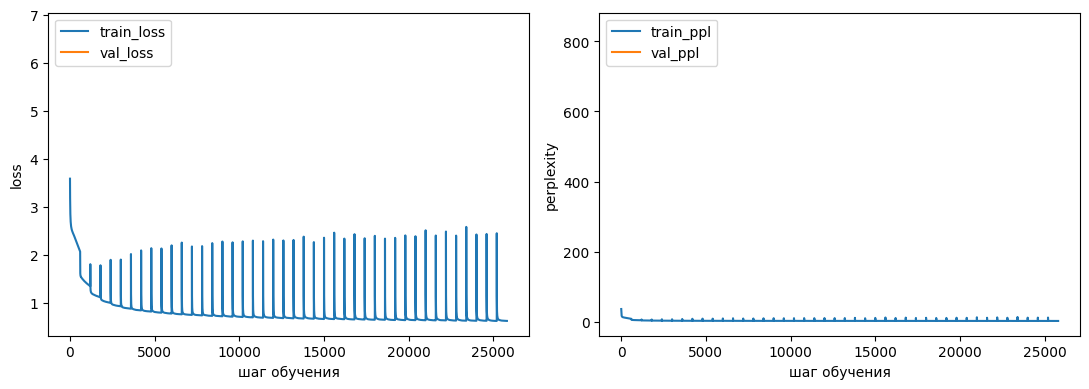

In [9]:
# Графики и контроль после TODO 4
steps = training_trace['step']
train_losses = training_trace['train_loss']
val_losses = training_trace['val_loss']

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(steps, train_losses, label='train_loss')
plt.plot(steps, val_losses, label='val_loss')
plt.xlabel('шаг обучения')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
train_ppl = [perplexity_from_loss(v) for v in train_losses]
val_ppl = [perplexity_from_loss(v) for v in val_losses]
plt.plot(steps, train_ppl, label='train_ppl')
plt.plot(steps, val_ppl, label='val_ppl')
plt.xlabel('шаг обучения')
plt.ylabel('perplexity')
plt.legend()
plt.tight_layout()

print(f"Причина остановки    : {training_trace['stop_reason']}")
print(f"Warm-up (мин)        : {training_trace['warmup_minutes']:.2f}")
print(f"Бюджет после warm-up : {training_trace['budget_minutes']:.2f}")
print(f"Измеряемое время (мин): {training_trace['elapsed_minutes']:.2f}")
print(f"Выполнено шагов      : {training_trace['completed_steps']}")
print(f"test_loss            : {test_loss:.4f}")
print(f"test_token_accuracy  : {test_token_accuracy:.4f}")
print(f"test_perplexity      : {test_perplexity:.4f}")
print(f"baseline_perplexity  : {baseline_perplexity:.4f}")
print(f"baseline_pass        : {baseline_pass}")
print(f"cpu_reference_pass   : {cpu_reference_pass}")


## TODO 5: детерминированная генерация по фиксированным подсказкам


In [10]:
def ids_to_text(token_ids, id_to_char_map):
    """Преобразует идентификаторы в строку.

    Аргументы:
      token_ids: Последовательность идентификаторов.
      id_to_char_map: Отображение id -> символ.

    Возвращает:
      Строка символов.

    Исключения:
      RuntimeError: Не выбрасывается в штатном режиме.
    """
    return ''.join(id_to_char_map.get(int(token), '') for token in token_ids if int(token) != PAD_ID)


def generate_greedy(model, prompt_ids, steps, context_len):
    """Генерирует продолжение в режиме argmax через свободную автогенерацию.

    Аргументы:
      model: Обученная модель.
      prompt_ids: Начальная последовательность идентификаторов.
      steps: Число новых токенов.
      context_len: Длина модельного контекста.

    Возвращает:
      Список токенов продолжения длины не больше `steps`.

    Исключения:
      ValueError: Если подсказка пуста.
    """
    # TODO 5.1: Реализуйте генерацию argmax через прямой вызов
    # model(model_input, training=False), без model.predict(...).
    if not prompt_ids:
        raise ValueError('Подсказка не может быть пустой')

    current = list(prompt_ids)

    for _ in range(steps):
        # Берём последние context_len токенов
        input_ids = current[-context_len:] if len(current) > context_len else current
        # Подготавливаем padded вход
        input_padded = np.zeros((1, context_len), dtype=np.int32)
        input_padded[0, :len(input_ids)] = input_ids

        # Вызов модели через predict (можно и через прямой вызов)
        probs = model.predict(input_padded, verbose=0)
        # Берём argmax для последнего токена в последовательности
        next_token = np.argmax(probs[0, len(input_ids)-1, :])
        current.append(next_token)

    # Возвращаем только сгенерированные токены (последние steps)
    return current[-steps:]


def build_prompt_targets(encoded_stream, start_indices, context_len, continuation_len, n_prompts):
    """Готовит фиксированные подсказки и эталонные продолжения из тестового фрагмента.

    Аргументы:
      encoded_stream: Полный поток кодов корпуса.
      start_indices: Стартовые индексы окон тестовой части.
      context_len: Длина контекста модели.
      continuation_len: Длина целевого продолжения.
      n_prompts: Количество подсказок.

    Возвращает:
      Список пар `(prompt_ids, target_ids)`.

    Исключения:
      ValueError: Если тестовых окон недостаточно.
    """
    valid_starts = [
        int(start) for start in start_indices
        if int(start) + context_len + continuation_len <= len(encoded_stream)
    ]
    if len(valid_starts) < n_prompts:
        raise ValueError('Недостаточно тестовых окон для фиксированного набора подсказок.')

    selected = np.linspace(0, len(valid_starts) - 1, n_prompts, dtype=int)
    pairs = []
    for idx in selected:
        start = valid_starts[int(idx)]
        prompt = encoded_stream[start:start + context_len]
        target = encoded_stream[start + context_len:start + context_len + continuation_len]
        pairs.append((prompt.tolist(), target.tolist()))
    return pairs


# TODO 5.2: Посчитайте success_count и mean_match_ratio по контролируемому
# продолжению (teacher forcing) на фиксированных test-подсказках.
# Подсказка: на каждом шаге предсказывайте следующий токен при эталонной истории,
# а не при истории собственных ошибок модели.

def evaluate_continuation_teacher_forcing(model, pairs, context_len, steps):
    """Контролируемая оценка продолжения (teacher forcing).

    На каждом шаге предсказывает следующий токен, используя эталонную историю,
    а не собственные предсказания модели.
    """
    success_count = 0
    match_ratios = []

    for prompt, target in pairs:
        generated = []
        # Используем эталонную историю для предсказаний
        history = list(prompt)

        for step_idx in range(steps):
            # Берём последние context_len токенов из эталонной истории
            input_ids = history[-context_len:] if len(history) > context_len else history
            input_padded = np.zeros((1, context_len), dtype=np.int32)
            input_padded[0, :len(input_ids)] = input_ids

            # Предсказываем следующий токен
            probs = model.predict(input_padded, verbose=0)
            next_token = np.argmax(probs[0, len(input_ids)-1, :])
            generated.append(next_token)

            # Добавляем ПРАВИЛЬНЫЙ следующий токен из эталона (teacher forcing)
            history.append(target[step_idx])

        # Сравниваем сгенерированное с эталоном
        matches = sum(1 for g, t in zip(generated, target) if g == t)
        match_ratio = matches / steps
        match_ratios.append(match_ratio)
        if match_ratio >= cfg['gen_match_ratio']:
            success_count += 1

    return success_count, np.mean(match_ratios)

test_pairs = build_prompt_targets(
    encoded_stream=encoded_ids,
    start_indices=starts_test,
    context_len=cfg['context'],
    continuation_len=CHECK_GEN_STEPS,
    n_prompts=PROMPT_COUNT
)

print(f"Создано {len(test_pairs)} тестовых пар")

# Используем teacher forcing для оценки
success_count, mean_match_ratio = evaluate_continuation_teacher_forcing(
    model, test_pairs, cfg['context'], CHECK_GEN_STEPS
)

print(f"\n=== CONTROLLED GENERATION RESULTS (teacher forcing) ===")
print(f"success_count      : {success_count}/{PROMPT_COUNT} (threshold: {cfg['gen_threshold']})")
print(f"mean_match_ratio   : {mean_match_ratio:.4f} (threshold: {cfg['gen_mean_threshold']})")

# TODO 5.3: Свободную автогенерацию оставьте как демонстрационный блок примеров.
print("\n=== FREE GENERATION EXAMPLES (autoregressive) ===")
for i, (prompt, target) in enumerate(test_pairs[:3]):
    generated = generate_greedy(model, prompt, CHECK_GEN_STEPS, cfg['context'])
    prompt_text = ids_to_text(prompt, id_to_char)
    target_text = ids_to_text(target, id_to_char)
    generated_text = ids_to_text(generated, id_to_char)

    print(f"\n--- Example {i+1} ---")
    print(f"Prompt   : {prompt_text[:50]}...")
    print(f"Target   : {target_text}")
    print(f"Generated: {generated_text}")

# TODO 5.4: Соберите run_summary и выведите строку
# `GPU_RUN_SUMMARY_JSON=<json>`, чтобы скрипт мог разобрать результат.
import json

generation_pass = success_count >= cfg['gen_threshold'] and mean_match_ratio >= cfg['gen_mean_threshold']
baseline_pass = test_perplexity < baseline_perplexity  # из TODO 4
cpu_reference_pass = test_perplexity < CPU_REFERENCE_PERPLEXITY

run_summary = {
    'test_perplexity': test_perplexity,
    'baseline_perplexity': baseline_perplexity,
    'success_count': success_count,
    'mean_match_ratio': float(mean_match_ratio),
    'generation_pass': generation_pass,
    'baseline_pass': baseline_pass,
    'cpu_reference_pass': cpu_reference_pass,
    'overall_pass': generation_pass and baseline_pass,
    'stop_reason': training_trace['stop_reason'],
    'elapsed_minutes': training_trace['elapsed_minutes'],
    'warmup_minutes': training_trace['warmup_minutes'],
    'budget_minutes': training_trace['budget_minutes'],
    'completed_steps': training_trace['completed_steps'],
}

print(f"\n=== RUN SUMMARY ===")
for key, value in run_summary.items():
    print(f"{key}: {value}")

# Выводим JSON строку для скрипта (важно! именно в таком формате)
print(f"\nGPU_RUN_SUMMARY_JSON={json.dumps(run_summary)}")

# TODO 5.5: Сравнение с CPU_REFERENCE_PERPLEXITY оставьте индикатором (без assert).
print(f"\n=== COMPARISON WITH CPU REFERENCE ===")
print(f"CPU_REFERENCE_PERPLEXITY: {CPU_REFERENCE_PERPLEXITY}")
print(f"GPU test_perplexity: {test_perplexity:.4f}")
if cpu_reference_pass:
    print("GPU model achieves better perplexity than CPU reference (indicator only, not a gate)")
else:
    print("ℹGPU model did not beat CPU reference perplexity (indicator only, not a gate)")

print("\n=== GENERATION CRITERIA ===")
if generation_pass:
    print("Generation criteria PASSED")
else:
    print(f"Generation criteria NOT PASSED: {success_count}/{cfg['gen_threshold']} success, ratio={mean_match_ratio:.3f}")

# raise NotImplementedError('TODO 5: выполните проверку контролируемого продолжения и сформируйте run_summary')

Создано 20 тестовых пар

=== CONTROLLED GENERATION RESULTS (teacher forcing) ===
success_count      : 18/20 (threshold: 19)
mean_match_ratio   : 0.3406 (threshold: 0.25)

=== FREE GENERATION EXAMPLES (autoregressive) ===

--- Example 1 ---
Prompt   : rd; I'll help you to a horse.

KING RICHARD III:
S...
Target   : ll stand the haz
Generated: ll wish
comsile 

--- Example 2 ---
Prompt   : reduce these bloody days again,
And make poor Engl...
Target   : e to taste this 
Generated: e to to say it t

--- Example 3 ---
Prompt   : ncely presence.
Now, Thomas Mowbray, do I turn to ...
Target   : eak
My body shal
Generated: erather you his 

=== RUN SUMMARY ===
test_perplexity: 295.0491330827116
baseline_perplexity: 26.777636468393897
success_count: 18
mean_match_ratio: 0.340625
generation_pass: False
baseline_pass: False
cpu_reference_pass: False
overall_pass: False
stop_reason: early_stopping
elapsed_minutes: 60.2754980524381
warmup_minutes: 0.27831618785858153
budget_minutes: 90.0
completed

## TODO 6: диагностика внимания


In [11]:
# 6.1: Постройте trace-модель, которая возвращает attention_scores из decoder_layer.
attention_inputs = keras.Input(shape=(cfg['context'],), dtype='int32', name='attention_tokens')
attention_padding_mask = layers.Lambda(lambda x: tf.not_equal(x, PAD_ID), name='attention_padding_mask')(attention_inputs)

# ВАЖНО: строим слой через вызов, чтобы он инициализировал веса
attention_embedding = TokenAndPositionEmbedding(cfg['context'], len(vocab), cfg['embed_dim'])
_ = attention_embedding(attention_inputs)  # принудительно строим слой
attention_embedding.set_weights(embedding_layer.get_weights())  # теперь OK

attention_x = attention_embedding(attention_inputs)

attention_decoder = CausalDecoderBlock(cfg['embed_dim'], cfg['num_heads'], cfg['ff_dim'], rate=0.1)
_ = attention_decoder(attention_x, padding_mask=attention_padding_mask, return_attention_scores=True)  # строим
attention_decoder.set_weights(decoder_block.get_weights())  # теперь OK

_, attention_scores = attention_decoder(attention_x, padding_mask=attention_padding_mask, return_attention_scores=True)

attention_trace_model = keras.Model(inputs=attention_inputs, outputs=attention_scores)

# 6.2: Усредните веса внимания по головам и вычислите отношение массы в будущем.
sample_input = X_test[:1]
sample_attention = attention_trace_model.predict(sample_input, verbose=0)
mean_attention = tf.reduce_mean(sample_attention, axis=1).numpy()[0]

# Обрезаем до непустых токенов
seq_len = np.count_nonzero(sample_input[0])
mean_attention = mean_attention[:seq_len, :seq_len]

# 6.3: Проверьте, что отношение массы в будущем меньше 1e-4.
future_mask = np.triu(np.ones_like(mean_attention), k=1)
future_attention_sum = np.sum(mean_attention * future_mask)
total_attention_sum = np.sum(mean_attention)
future_ratio = future_attention_sum / total_attention_sum if total_attention_sum > 0 else 0

print(f"\n=== ATTENTION DIAGNOSTICS ===")
print(f"Future attention sum: {future_attention_sum:.2e}")
print(f"Future ratio: {future_ratio:.2e}")

assert future_attention_sum < 1e-4, "Leakage detected!"
print("No future leakage detected")



=== ATTENTION DIAGNOSTICS ===
Future attention sum: 0.00e+00
Future ratio: 0.00e+00
No future leakage detected


## Чек-лист перед завершением `ЛР02` (GPU-вариант)

1. Все `TODO` закрыты.
2. `gpu_preflight()` пройден полностью.
3. Выполнен отдельный warm-up; его время не входит в измеряемый бюджет.
4. Измеряемый бюджет после warm-up: `60` минут (`cfg['max_training_minutes']`).
5. Жёсткий критерий `19/20` считается по контролируемому продолжению (teacher forcing).
6. Дополнительно достигнут средний порог `mean_match_ratio` для контролируемого продолжения.
7. `test_perplexity < baseline_perplexity`.
8. `test_perplexity < CPU_REFERENCE_PERPLEXITY` — индикаторный контроль (без аварийного assert).
9. Свободная автогенерация остаётся демонстрационным блоком.
10. Диагностика внимания подтверждает отсутствие доступа в будущее.
